# Range Doppler Backgecode

1. ERSDAC CEOS Product I/O
2. Zero Doppler Estimetion
3. Range Doppler Equation
4. Backgecode Implimentation

## CEOS Format L1.1 L1.5
https://www.eorc.jaxa.jp/ALOS/jp/alos/fdata/PALSAR_x_Format_JL.pdf

記事にて紹介コード

In [ ]:
import os

# 環境変数設定
os.environ['MKL_ENABLE_INSTRUCTIONS'] = 'SSE4_2'
import numpy as np
import warnings
import tifffile
import scipy
import cv2
from tqdm import tqdm

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

In [2]:
PATH_ROOT_ALOS_M = '../data/sakurazima/ALPSRP216690620-H1.1__A/'

PATH_OUTPUT = os.path.join('output', '307')
os.makedirs(PATH_OUTPUT, exist_ok=True)

In [3]:
from utils.ceos_io import ALOSPALSARData
from utils.interferogram import get_slant_range

alos_m = ALOSPALSARData(PATH_ROOT_ALOS_M)
slc_m = alos_m.read_slc()
pos_m = alos_m.read_location()
(orb_m, vel_m, obs_m) = alos_m.read_orbit(velocity=True)
(A, B, CS, CL) = alos_m.read_geo_matrix()
print('ALOS `M`ain Path Geo Matrix:  \n', A.shape, B.shape, CS, CL)

xyz_m_loc, (idx_sample, idx_line) = alos_m.read_xyz_raster(A, B, CS, CL)
print('ALOS `M`ain Path Geo Obsebasion Area Raster:  \n', xyz_m_loc.shape)
slant_m = get_slant_range(orb_m, xyz_m_loc, idx_line)

Reading Signal...: 100%|███████████████▉| 18431/18432 [00:14<00:00, 1278.59it/s]


ALOS `M`ain Path Geo Matrix:  
 (5, 5) (5, 5) 4672.0 9216.0
ALOS `M`ain Path Geo Obsebasion Area Raster:  
 (18432, 9344, 3)


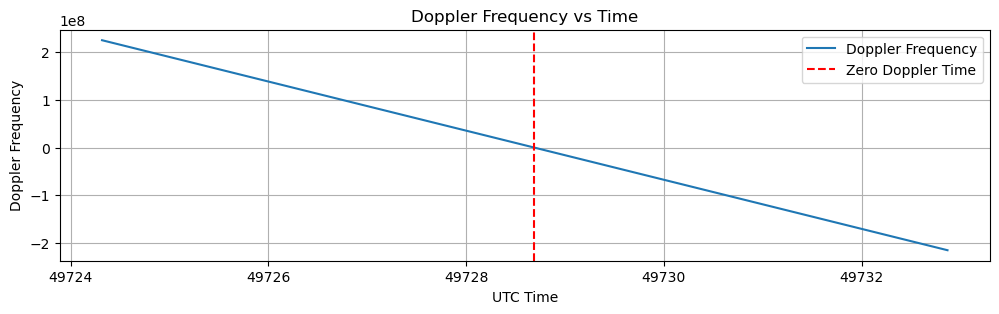

In [4]:
sensor_position = orb_m
sensor_velocity = vel_m
earth_point = xyz_m_loc[int(CL), int(CS), :]
dopp_freqs = sensor_velocity[:, 0] * (earth_point[0] - sensor_position[:, 0]) + \
                   sensor_velocity[:, 1] * (earth_point[1] - sensor_position[:, 1]) + \
                   sensor_velocity[:, 2] * (earth_point[2] - sensor_position[:, 2])
                   
def get_index(arr, val):
    idx = np.abs(arr - val).argmin()
    return idx

zero_time = obs_m[get_index(dopp_freqs, 0)]

plt.figure(figsize=(12, 3), dpi=100, facecolor='w', edgecolor='k')
plt.plot(obs_m, dopp_freqs)
plt.axvline(x=zero_time, color='r', linestyle='--')
plt.xlabel('UTC Time')
plt.ylabel('Doppler Frequency')
plt.title('Doppler Frequency vs Time')
plt.grid()
plt.legend(['Doppler Frequency', 'Zero Doppler Time'])
plt.savefig(os.path.join(PATH_OUTPUT, 'doppler_frequency_vs_time.png'))

## Compute From LLA

`Earth Center Point ECEF:  [-3549118.77857871  4111741.75378195  3332137.10346926]`

In [5]:
from utils.ceos_io import transform_latlogalt_earthfixearthcenter_coordirate

In [6]:
def get_change_sgin(arr):
    idx = np.where(np.sign(arr[:-1]) != np.sign(arr[1:]))[0]
    return idx[0] # asume only one zero point

def get_slant_range(time, orbit, earth_point):
    sensor_pos = orbit[time]
    x_diff = sensor_pos[0] - earth_point[0]
    y_diff = sensor_pos[1] - earth_point[1]
    z_diff = sensor_pos[2] - earth_point[2]
    return np.sqrt(x_diff ** 2 + y_diff ** 2 + z_diff ** 2)

def get_zero_doppler(orb_m, vel_m, target_pos):
    dopp_freqs = vel_m[:, 0] * (orb_m[:, 0] - target_pos[0]) + \
                 vel_m[:, 1] * (orb_m[:, 1] - target_pos[1]) + \
                 vel_m[:, 2] * (orb_m[:, 2] - target_pos[2])
    zero_doppler_idx = get_change_sgin(dopp_freqs, )
    return dopp_freqs[zero_doppler_idx], zero_doppler_idx

def range_doppler_forward(lat, lon, alt, slant, slc):
    target_pos = transform_latlogalt_earthfixearthcenter_coordirate(lat*np.pi/180, lon*np.pi/180, alt, stack_axis=0)
    zero_dopp, zero_dopp_idx = get_zero_doppler(orb_m, vel_m, target_pos)
    slant_zero_dopp_time = get_slant_range(zero_dopp_idx, orb_m, target_pos,)
    slant_idx = get_index(slant[zero_dopp_idx], slant_zero_dopp_time)
    slc_zero_dopp_time = slc[zero_dopp_idx, slant_idx]
    return slc_zero_dopp_time

def range_doppler_backward(points, sample_lat, sample_lon, alt=0):
    lats = np.linspace(points[0][1],points[1][1], sample_lat)
    lons = np.linspace(points[0][0],points[1][0], sample_lon)

    gecoded_plane = np.zeros((sample_lat, sample_lon), dtype=np.complex64)
    for i, lat in tqdm(enumerate(lats), total=sample_lat):
        for j, lon in enumerate(lons):

            if isinstance(alt, int):
                alt_ij = alt
            else:
                alt_ij = alt[i, j]

            gecoded_plane[i, j] = range_doppler_forward(lat, lon, alt_ij, slant_m, slc_m[0])
    return gecoded_plane

## Geocode

100%|██████████| 1200/1200 [02:29<00:00,  8.01it/s]


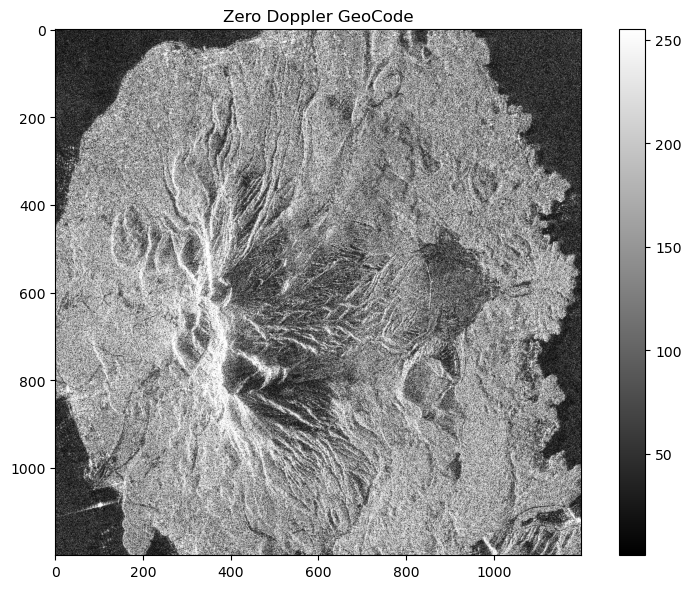

In [7]:
sample_lat = 1200
sample_lon = 1200

# sample area (Longitude, Latitude, Altitude)
points = [
    (130.60652,31.61737, 40),  # top left
    (130.72007,31.54760, 40),  # bottom right
]

gecoded_plane = range_doppler_backward(points, sample_lat, sample_lon, alt=0)
gecoded_plane_amp = np.abs(gecoded_plane)
        
plt.figure(figsize=(8, 6), dpi=100, facecolor='w', edgecolor='k')
plt.title('Zero Doppler GeoCode')
plt.imshow(gecoded_plane_amp, cmap='gray')
plt.colorbar()
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, f'zero_doppler_geocode_res{sample_lat}-{sample_lon}.png'))
plt.show();plt.clf();plt.close()

In [8]:
import rasterio
from rasterio.crs import CRS
from affine import Affine

# 位置情報を書き込み
PATH_TIFF = os.path.join(PATH_OUTPUT, 'zero_doppler_geocode.tif')

x_res = (points[0][0] - points[1][0]) / sample_lon
y_res = (points[0][1] - points[1][1]) / sample_lat
tf_affine = Affine(x_res, 0, points[1][0], 0, y_res, points[1][1])

with rasterio.open(
                PATH_TIFF, 'w', driver='GTiff', 
                height=sample_lat, width=sample_lon, 
                count=1, dtype=np.float32, 
                crs=CRS.from_epsg(4326), 
                transform=tf_affine) as dst:
    dst.write(gecoded_plane_amp[::-1, ::-1], 1) # ascending flip

## Ortho

100%|██████████| 1200/1200 [02:27<00:00,  8.14it/s]


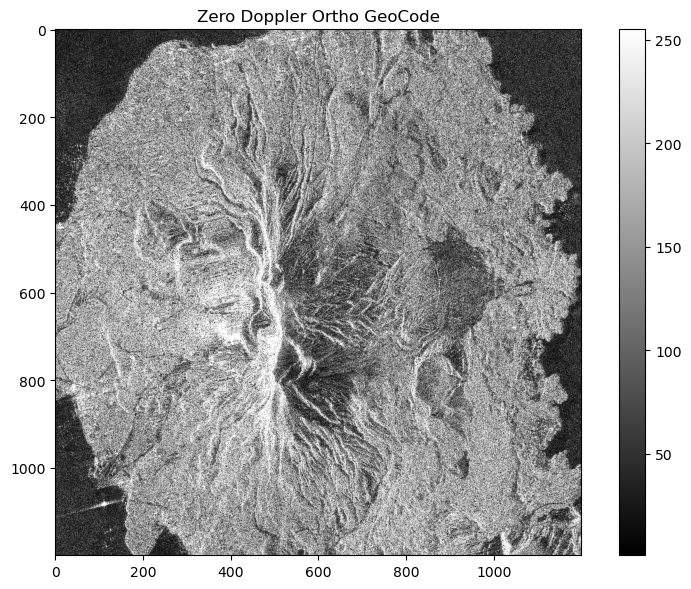

In [9]:
PATH_DEM_CUT = '../data/sakurazima/srtm_dem_sakurazima_cut_height_area.tif'
dem = tifffile.imread(PATH_DEM_CUT).astype(np.float32)
dem = np.where(dem < 0, 0, dem) # preprocess 
dem_resample = cv2.resize(dem, (sample_lon, sample_lat), interpolation=cv2.INTER_LINEAR)

geoid = 40
dem_resample += geoid

gecoded_plane_ortho = range_doppler_backward(points, 
    sample_lat, sample_lon, alt=dem_resample)
gecoded_plane_ortho_amp = np.abs(gecoded_plane_ortho)
        
plt.figure(figsize=(8, 6), dpi=100, facecolor='w', edgecolor='k')
plt.title('Zero Doppler Ortho GeoCode')
plt.imshow(gecoded_plane_ortho_amp, cmap='gray')
plt.colorbar()
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, f'zero_doppler_ortho_geocode_res{sample_lat}-{sample_lon}.png'))
plt.show();plt.clf();plt.close()


In [10]:
# 位置情報を書き込み
PATH_TIFF = os.path.join(PATH_OUTPUT, f'zero_doppler_geocode_ortho_res{sample_lat}-{sample_lon}.tif')

x_res = (points[0][0] - points[1][0]) / sample_lon
y_res = (points[0][1] - points[1][1]) / sample_lat
tf_affine = Affine(x_res, 0, points[1][0], 0, y_res, points[1][1])

with rasterio.open(
                PATH_TIFF, 'w', driver='GTiff', 
                height=sample_lat, width=sample_lon, 
                count=1, dtype=np.float32, 
                crs=CRS.from_epsg(4326), 
                transform=tf_affine) as dst:
    dst.write(gecoded_plane_ortho_amp[::-1, ::-1], 1) # ascending flip

100%|██████████| 1200/1200 [02:27<00:00,  8.16it/s]


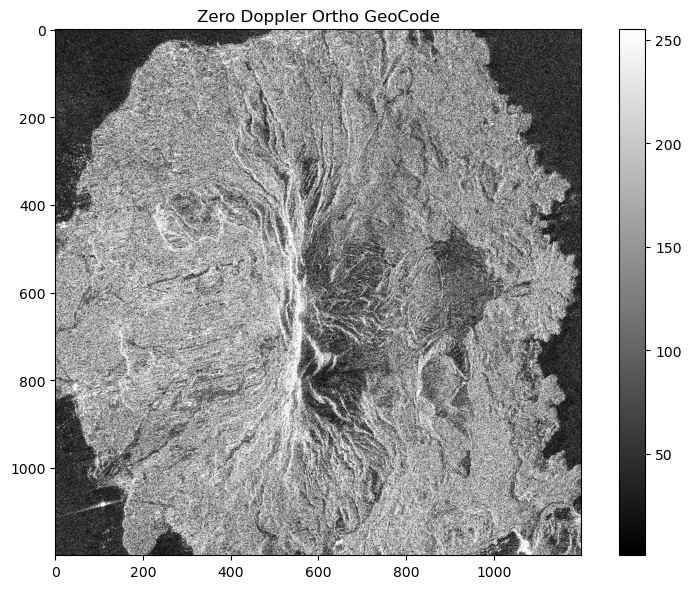

In [11]:
PATH_DEM_CUT = '../data/sakurazima/srtm_dem_sakurazima_cut_height_area.tif'
dem = tifffile.imread(PATH_DEM_CUT).astype(np.float32)
dem = np.where(dem < 0, 0, dem) # preprocess 
dem_resample = cv2.resize(dem, (sample_lon, sample_lat), interpolation=cv2.INTER_LINEAR)

scale = 2
dem_resample *=scale

gecoded_plane_ortho_scale = range_doppler_backward(points, sample_lat, sample_lon, alt=dem_resample)
gecoded_plane_ortho_scale_amp = np.abs(gecoded_plane_ortho_scale)
        
plt.figure(figsize=(8, 6), dpi=100, facecolor='w', edgecolor='k')
plt.title('Zero Doppler Ortho GeoCode')
plt.imshow(gecoded_plane_ortho_scale_amp, cmap='gray')
plt.colorbar()
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, f'zero_doppler_ortho_geocode_res{sample_lat}-{sample_lon}_scale{scale}.png'))
plt.show();plt.clf();plt.close()

In [12]:
# 位置情報を書き込み
PATH_TIFF = os.path.join(PATH_OUTPUT, f'zero_doppler_geocode_ortho_res{sample_lat}-{sample_lon}_scale{scale}.tif')

x_res = (points[0][0] - points[1][0]) / sample_lon
y_res = (points[0][1] - points[1][1]) / sample_lat
tf_affine = Affine(x_res, 0, points[1][0], 0, y_res, points[1][1])

with rasterio.open(
                PATH_TIFF, 'w', driver='GTiff', 
                height=sample_lat, width=sample_lon, 
                count=1, dtype=np.float32, 
                crs=CRS.from_epsg(4326), 
                transform=tf_affine) as dst:
    dst.write(gecoded_plane_ortho_scale_amp[::-1, ::-1], 1) # ascending flip

## Altitude Effect

Doppler Frequency at h=0:  -20207.013835191727 Index:  7609


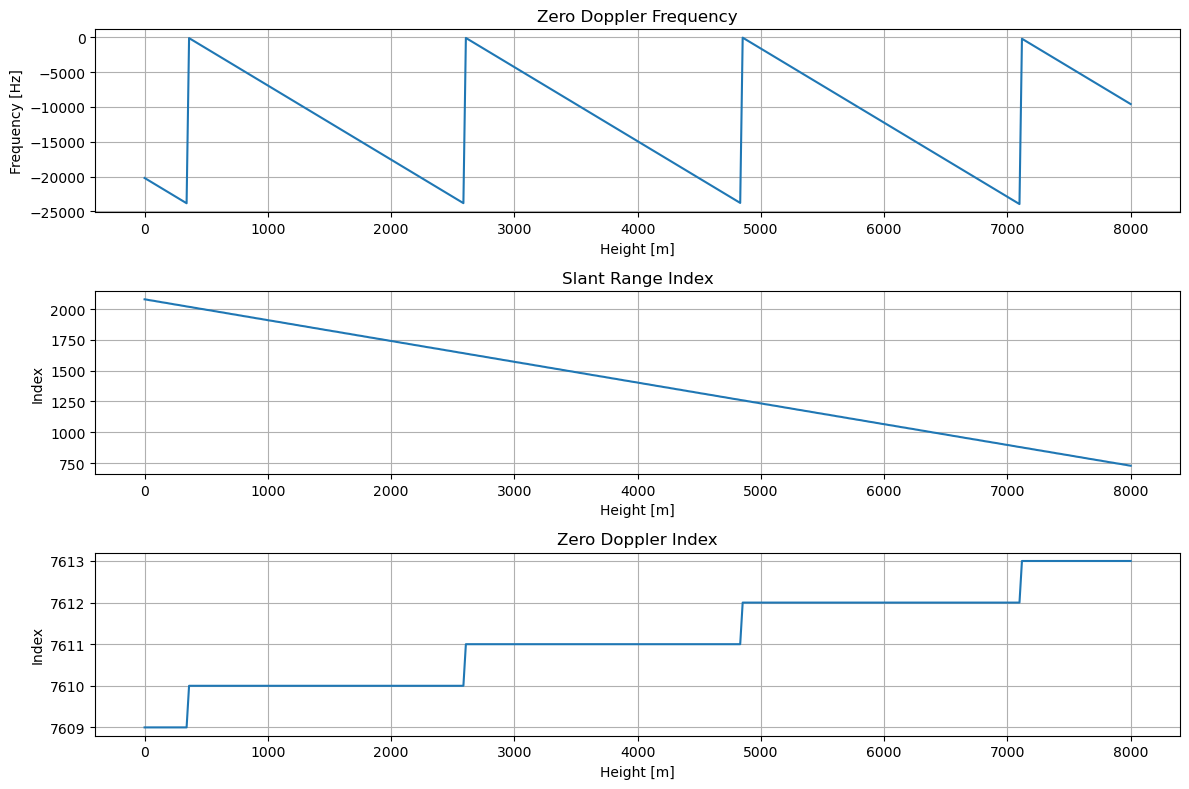

In [13]:
H = 8000

heights = np.linspace(0, H, 400)
freq_s = []
indexes_r = []
indexes_a = []

target_pos_h0 = transform_latlogalt_earthfixearthcenter_coordirate(
        points[0][1]*np.pi/180, points[0][0]*np.pi/180, 0, stack_axis=0)
zero_dopp_h0, zero_dopp_h0_idx = get_zero_doppler(orb_m, vel_m, target_pos_h0)
print('Doppler Frequency at h=0: ', zero_dopp_h0, 'Index: ', zero_dopp_h0_idx)

for _h in heights:
    target_pos = transform_latlogalt_earthfixearthcenter_coordirate(
        points[0][1]*np.pi/180, points[0][0]*np.pi/180, _h, stack_axis=0)
    doppler_frequency, dopp_idx = get_zero_doppler(orb_m, vel_m, target_pos)
    slant_zero_dopp_time = get_slant_range(dopp_idx, orb_m, target_pos,)
    slant_idx = get_change_sgin(slant_m[dopp_idx]-slant_zero_dopp_time, )
    
    freq_s.append(doppler_frequency)
    indexes_r.append(slant_idx)
    indexes_a.append(dopp_idx)

plt.figure(figsize=(12, 8), dpi=100, facecolor='w', edgecolor='k')
plt.subplot(3, 1, 1)
plt.title('Zero Doppler Frequency')
plt.plot(heights, freq_s)
plt.xlabel('Height [m]')
plt.ylabel('Frequency [Hz]')
plt.grid()
plt.subplot(3, 1, 2)
plt.title('Slant Range Index')
plt.plot(heights, indexes_r)
plt.xlabel('Height [m]')
plt.ylabel('Index')
plt.grid()
plt.subplot(3, 1, 3)
plt.title('Zero Doppler Index')
plt.plot(heights, indexes_a)
plt.xlabel('Height [m]')
plt.ylabel('Index')
plt.grid()

plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, f'zero_doppler_frequency_height.png'))
plt.show();plt.clf();plt.close()